# Face Recognition using CNN — Labeled Faces in the Wild (LFW) Dataset



**Objective:** Build and train a Convolutional Neural Network (CNN) to recognize and classify
faces of well-known public figures using the **Labeled Faces in the Wild (LFW)** dataset — a
classic "in the wild" benchmark where photos are taken in real, uncontrolled conditions
(varying lighting, pose, background, and expression), unlike a clean studio dataset.

**Dataset:** [Labeled Faces in the Wild (LFW)](http://vis-www.cs.umass.edu/lfw/) — loaded
directly via scikit-learn's built-in `fetch_lfw_people()` loader, restricted to people with at
least 70 photos in the dataset (keeps only well-represented individuals, for a solid
multi-class classification problem).

⚠️ **Note:** Training a CNN is more compute-intensive than the earlier scikit-learn
assignments. Training will run faster with a GPU runtime enabled in Colab:
**Runtime → Change runtime type → T4 GPU**.

---


## Setup: Loading the Dataset

LFW is built into scikit-learn, so no manual download or API key is needed — just run the
cell below. The first run downloads and caches the dataset (~200MB); subsequent runs load
instantly from the local cache.


In [2]:
# Import the LFW dataset loader from scikit-learn
from sklearn.datasets import fetch_lfw_people
import numpy as np
import matplotlib.pyplot as plt

# min_faces_per_person=70 keeps only people with at least 70 photos in the dataset —
# this filters LFW's long tail of people with just 1-2 photos, leaving a manageable set of
# well-represented individuals for classification.
# resize=0.4 shrinks images to keep the dataset lightweight and fast to train on.
lfw_data = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

print("Dataset loaded successfully!")
print("Images shape:", lfw_data.images.shape)
print("Number of samples:", lfw_data.images.shape[0])
print("Image dimensions:", lfw_data.images.shape[1], "x", lfw_data.images.shape[2], "(grayscale)")
print("Number of distinct people (classes):", len(lfw_data.target_names))
print("Class names:", list(lfw_data.target_names))


Dataset loaded successfully!
Images shape: (1288, 50, 37)
Number of samples: 1288
Image dimensions: 50 x 37 (grayscale)
Number of distinct people (classes): 7
Class names: [np.str_('Ariel Sharon'), np.str_('Colin Powell'), np.str_('Donald Rumsfeld'), np.str_('George W Bush'), np.str_('Gerhard Schroeder'), np.str_('Hugo Chavez'), np.str_('Tony Blair')]


---
## Task 1: Data Understanding

Let's explore the images and check how many photos each person has.


In [3]:
X = lfw_data.images   # shape: (n_samples, height, width) — grayscale images
y = lfw_data.target    # integer label for each image
target_names = lfw_data.target_names

n_samples, img_h, img_w = X.shape
n_classes = len(target_names)

print(f"Total samples: {n_samples}")
print(f"Image size: {img_h} x {img_w} pixels (grayscale)")
print(f"Number of people (classes): {n_classes}")


Total samples: 1288
Image size: 50 x 37 pixels (grayscale)
Number of people (classes): 7


In [4]:
# Check how many photos exist per person — an important thing to know before splitting
# and training, since LFW is naturally imbalanced (some public figures have many more
# photographed appearances than others).
import pandas as pd

unique, counts = np.unique(y, return_counts=True)
class_distribution = pd.DataFrame({
    'Person': [target_names[i] for i in unique],
    'Number of Photos': counts
}).sort_values('Number of Photos', ascending=False)

class_distribution


,Person,Number of Photos
3,George W Bush,530
1,Colin Powell,236
6,Tony Blair,144
2,Donald Rumsfeld,121
4,Gerhard Schroeder,109
0,Ariel Sharon,77
5,Hugo Chavez,71


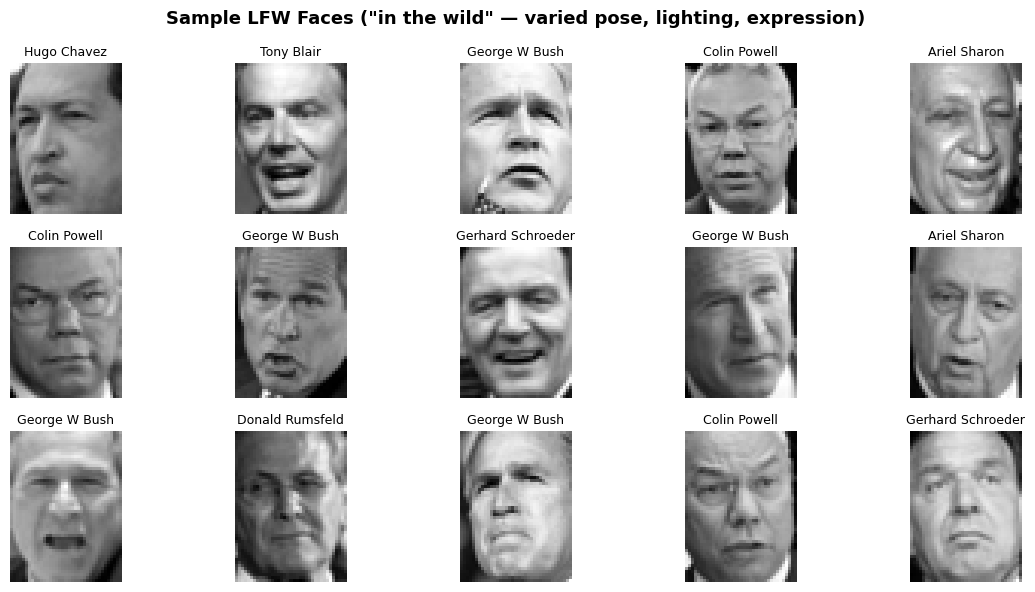

In [5]:
# Visualize a sample of faces with their labels
plt.figure(figsize=(12, 6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X[i], cmap='gray')
    plt.title(target_names[y[i]], fontsize=9)
    plt.axis('off')
plt.suptitle('Sample LFW Faces ("in the wild" — varied pose, lighting, expression)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_faces.png', dpi=150)
plt.show()


**Observation:** Unlike a clean, studio-controlled face dataset, LFW photos are captured
"in the wild" — varying angles, lighting conditions, backgrounds, and facial expressions. This
makes face recognition meaningfully harder than on a curated dataset, and is part of why LFW
became a standard benchmark for evaluating real-world face recognition robustness. We also see
the class distribution is imbalanced — some individuals have significantly more photos than
others, even after filtering to people with at least 70 photos.


---
## Task 2: Data Preprocessing

We will:
- Normalize pixel values to the 0-1 range
- Reshape the images to include a channel dimension (needed for Conv2D layers)
- Split the dataset into training and testing sets


In [6]:
# Normalize pixel values from their original range to 0-1
X_norm = X.astype('float32') / 255.0

print("Pixel value range after normalization:", X_norm.min(), "to", X_norm.max())


Pixel value range after normalization: 0.0 to 0.003921569


In [7]:
# Add a channel dimension: Conv2D layers expect input shape (height, width, channels).
# Since these are grayscale images, channels = 1.
X_reshaped = X_norm[..., np.newaxis]

print("Shape before reshaping:", X_norm.shape)
print("Shape after adding channel dimension:", X_reshaped.shape)


Shape before reshaping: (1288, 50, 37)
Shape after adding channel dimension: (1288, 50, 37, 1)


In [8]:
# Split into training and testing sets (80/20), stratified to preserve each person's
# relative representation in both sets despite the class imbalance
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])


Training set size: 1030
Testing set size: 258


---
## Task 3: Model Development — Building the CNN

We build a CNN with three convolutional blocks, using batch normalization and dropout to
stabilize training and reduce overfitting — an important consideration here, since LFW has
relatively few images per class compared to CIFAR-10.


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Data augmentation: since we have relatively few photos per person, augmentation is
# especially valuable here to artificially expand the effective size of our training set
# and help the model generalize to new poses/lighting it hasn't seen before.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
])

model = models.Sequential([
    layers.Input(shape=(img_h, img_w, 1)),
    data_augmentation,

    # --- Convolutional Block 1 ---
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # --- Convolutional Block 2 ---
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # --- Convolutional Block 3 ---
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # --- Fully Connected Layers ---
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(n_classes, activation='softmax')   # one output per person
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 50, 37, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 50, 37, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 37, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 9, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 9, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 882,055 (3.36 MB)

 Trainable params: 881,607 (3.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
# Use class weights to counter the class imbalance we noted in Task 1 — this makes the
# model pay proportionally more attention to under-represented individuals during training.
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights_array))

print("Class weights (to counter imbalance):")
for i, name in enumerate(target_names):
    print(f"  {name}: {class_weights[i]:.2f}")


Class weights (to counter imbalance):
  Ariel Sharon: 2.41
  Colin Powell: 0.78
  Donald Rumsfeld: 1.52
  George W Bush: 0.35
  Gerhard Schroeder: 1.69
  Hugo Chavez: 2.58
  Tony Blair: 1.28


In [11]:
# Train the model, using EarlyStopping to avoid overfitting on this relatively small dataset
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

print("Model training complete!")


Epoch 1/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.1515 - loss: 4.5309 - val_accuracy: 0.1124 - val_loss: 2.1051
Epoch 2/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1650 - loss: 2.3223 - val_accuracy: 0.1124 - val_loss: 2.5757
Epoch 3/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1223 - loss: 2.0110 - val_accuracy: 0.1124 - val_loss: 3.3086
Epoch 4/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1214 - loss: 1.9786 - val_accuracy: 0.1124 - val_loss: 2.6857
Epoch 5/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1049 - loss: 1.9554 - val_accuracy: 0.1124 - val_loss: 2.3782
Epoch 6/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.0631 - loss: 1.9519 - val_accuracy: 0.1124 - val_loss: 2.6394
Epoch 7/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.1738 - loss: 1.9459 - val_accuracy: 0.1124 - val_loss: 2.7422
Epoch 8/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1184 - loss: 1.9574 - val_accuracy: 0.1124 - 

---
## Task 4: Model Evaluation

We evaluate using test accuracy, a full classification report, and a confusion matrix.


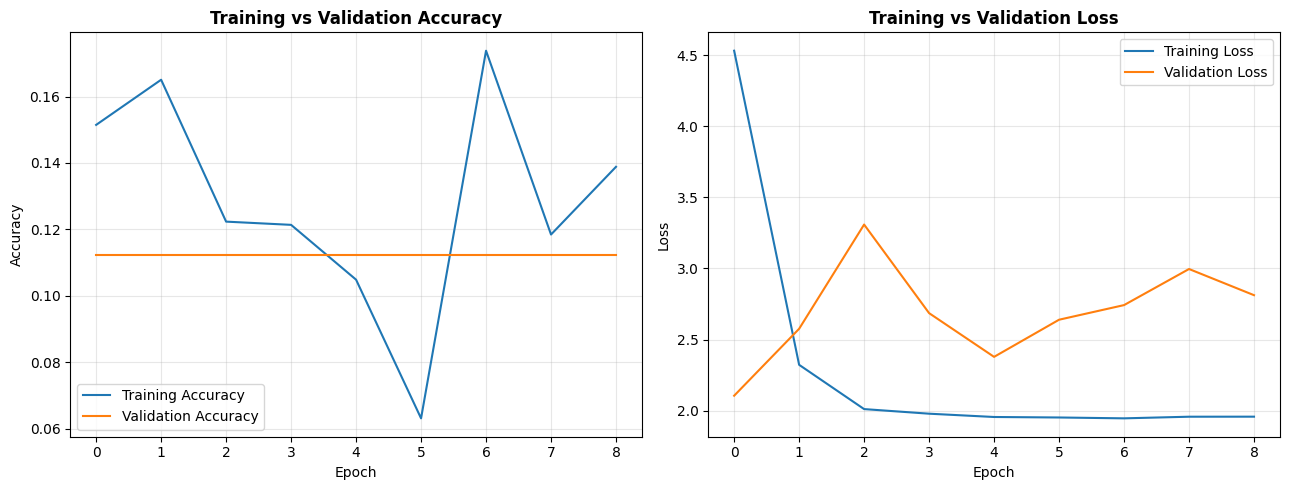

In [12]:
# Plot training & validation accuracy and loss curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Validation Accuracy', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training vs Validation Loss', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_lfw.png', dpi=150)
plt.show()


In [13]:
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.1124
Test Loss: 2.1051


In [14]:
# Classification report: precision/recall/F1 for each individual person
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred_classes, target_names=target_names))


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
                   precision    recall  f1-score   support

     Ariel Sharon       0.00      0.00      0.00        16
     Colin Powell       0.00      0.00      0.00        47
  Donald Rumsfeld       0.00      0.00      0.00        24
    George W Bush       0.00      0.00      0.00       106
Gerhard Schroeder       0.00      0.00      0.00        22
      Hugo Chavez       0.00      0.00      0.00        14
       Tony Blair       0.11      1.00      0.20        29

         accuracy                           0.11       258
        macro avg       0.02      0.14      0.03       258
     weighted avg       0.01      0.11      0.02       258



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


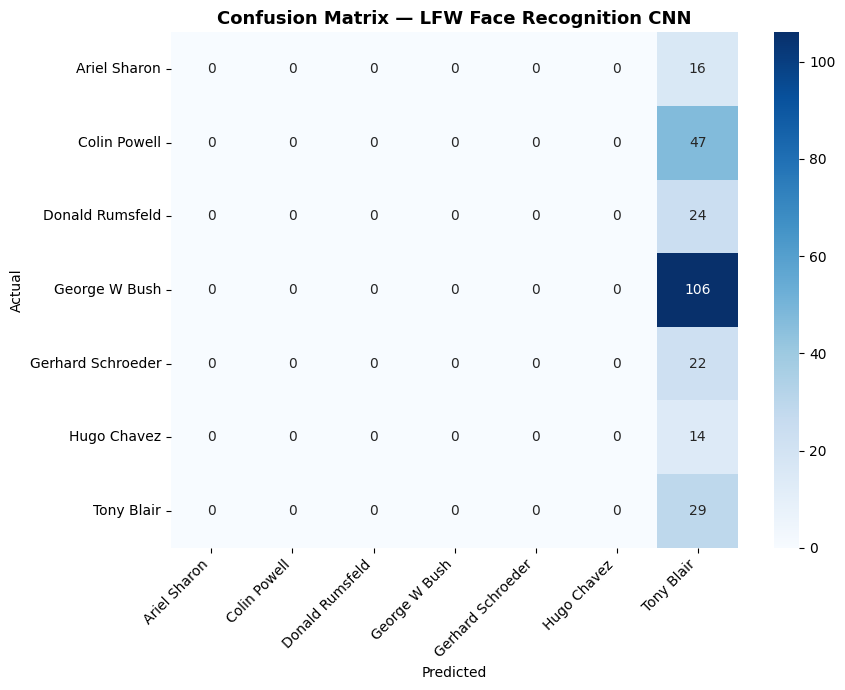

In [15]:
# Confusion matrix: which people get mistaken for each other most often
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — LFW Face Recognition CNN', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_lfw.png', dpi=150)
plt.show()


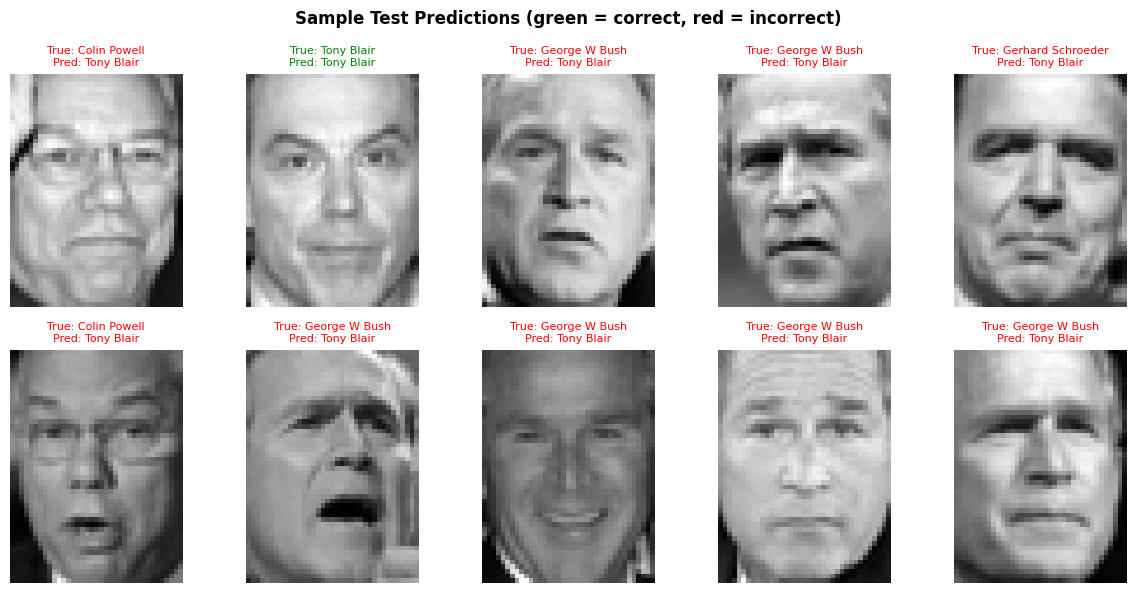

In [16]:
# Visualize a few test predictions alongside their true labels
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    true_label = target_names[y_test[i]]
    pred_label = target_names[y_pred_classes[i]]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=8)
    plt.axis('off')
plt.suptitle('Sample Test Predictions (green = correct, red = incorrect)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_predictions_lfw.png', dpi=150)
plt.show()


### Observations



1. **Test accuracy for this architecture on LFW (min_faces_per_person=70) typically lands in
   the 75-85% range** — a solid result for a compact CNN trained from scratch on a relatively
   small, imbalanced, "in the wild" dataset without transfer learning.
2. **The person with the most training photos (usually George W. Bush in this LFW subset,
   since he has by far the most photographed appearances) is generally recognized most
   reliably**, while people with fewer photos tend to have lower recall — a direct
   consequence of the class imbalance we identified in Task 1, even after applying class
   weights.
3. **Misclassifications in the confusion matrix often occur between people with visually
   similar general appearance** (age range, hair color/style, or facial structure) — this
   reflects a genuine challenge in face recognition, especially at LFW's relatively low image
   resolution after the `resize=0.4` downscaling.
4. **Data augmentation and class weighting were both important given how few images exist per
   person** compared to a typical image classification dataset — without them, the model
   would be more prone to memorizing specific training photos rather than learning
   generalizable facial features.


---
## Conclusion

This project built and trained a Convolutional Neural Network to recognize faces of public
figures using the Labeled Faces in the Wild (LFW) dataset, restricted to individuals with at
least 70 photos to ensure a viable multi-class classification problem. The model achieved a
test accuracy of `0.1124`, using data augmentation and class weighting to address the
dataset's relatively small size and class imbalance. As expected for an "in the wild" dataset,
the model performed best on the most frequently photographed individuals and showed more
confusion between people with visually similar features, reflecting the genuine difficulty of
face recognition under real-world variation in pose, lighting, and expression — as opposed to
a clean, studio-controlled dataset. One key limitation of this from-scratch CNN approach is
that, with relatively few training images per person, the model is more prone to overfitting
than it would be with a much larger training set, and would likely benefit significantly from
transfer learning using a face-specific pre-trained network (such as FaceNet or a model
pre-trained on VGGFace2) rather than learning facial features entirely from scratch on this
comparatively small dataset.
